##### <u>Инициализация</u>

In [1]:
# >>>>>>>>>> Init <<<<<<<<<<
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from matplotlib.patches import Ellipse

Treshold = 0.5  # Порог уверенности в найденном шаре

# Список цветов для различных классов
colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)]

# Load YOLO
model = YOLO('local/yolo_balls_11_new.pt')

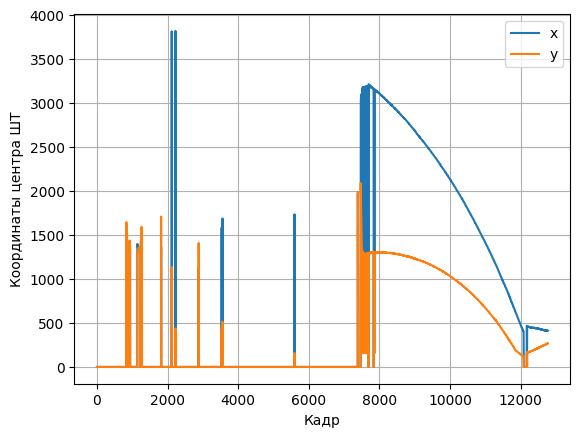

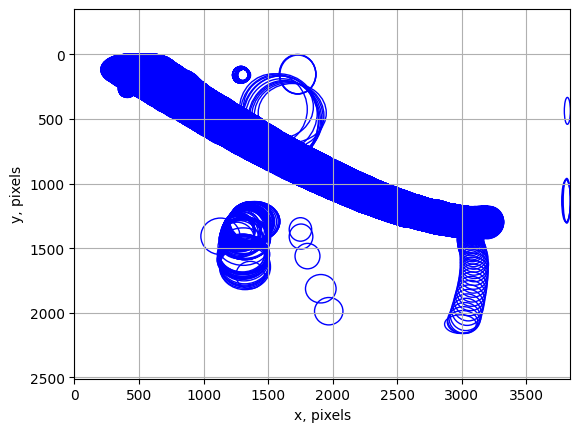

In [ ]:
for N_cam in [1,2,3]:
    framerate = [24.98, 25, 25][N_cam-1]
    Nimg = [12768, 13286, 7982][N_cam-1]
    path = f"local/videos/cam{N_cam}_undistort/"
    box_filename = f"local/result/boxes_{N_cam}.txt"

    # >>>>>>>>>> Find the balls <<<<<<<<<<
    f_balls = open(box_filename, 'w')
    boxes_in_frames = []

    for i in range(Nimg):
        # Открытие кадра 
        # if i%1000 == 0:
        #     t = i/framerate
        #     print(f"Кадр {i+1} ({t//60}:{t%60} video)")
        img = cv2.imread(f"{path}img{(i+1):05}.jpg")
        dh, dw, _ = img.shape

        # Обработка кадра с помощью модели YOLO
        results = model(img, verbose=False)
        for result in results:
            # Получение данных об объектах
            boxes_in_frame = []
            classes_names = result.names
            classes = result.boxes.cls.cpu().numpy()
            boxes = result.boxes.xyxy.cpu().numpy().astype(np.int32)

            for class_id, box, conf in zip(classes, boxes, result.boxes.conf):
                if conf > Treshold:
                    class_name = classes_names[int(class_id)]
                    color = colors[int(class_id) % len(colors)]
                    x1, y1, x2, y2 = box
                    boxes_in_frame += [box]
            boxes_in_frames += [boxes_in_frame]

            # Запись положения найденного тела
            n = len(boxes_in_frame)
            txt = f"{n} "
            for i in range(n):
                for j in range(4):
                    txt += f"{boxes_in_frame[i][j]} "
            f_balls.write(txt + "\n")

    # Освобождение ресурсов
    f_balls.close()

    # Отрисовка результатов, преобразование txt в csv
    x,y = [], []
    d = pd.DataFrame()
    with open(box_filename, 'r') as f:
        for it, line in enumerate(f):
            l = line.split()
            d.loc[it, 'detected'] = int(l[0])
            if int(l[0]) > 0:
                d.loc[it, 'x0'] = int(float(l[1]))
                d.loc[it, 'y0'] = int(float(l[2]))
                d.loc[it, 'x1'] = int(float(l[3]))
                d.loc[it, 'y1'] = int(float(l[4]))
                x.append((float(l[1]) + float(l[3])) / 2)
                y.append((float(l[2]) + float(l[4])) / 2)
            else:
                d.loc[it, 'x0'] = 0
                d.loc[it, 'y0'] = 0
                d.loc[it, 'x1'] = 0
                d.loc[it, 'y1'] = 0
                x.append(0)
                y.append(0)
    d.to_csv(f"local/result/{N_cam}.csv")
    plt.plot(x, label='x')
    plt.plot(y, label='y')
    plt.xlabel("Кадр")
    plt.ylabel("Координаты центра ШТ")
    plt.grid()
    plt.legend()
    plt.show()
    
    fig, ax = plt.subplots(subplot_kw={"aspect": "equal"})
    with open(box_filename, 'r') as f:
        for it, line in enumerate(f):
            l = line.split()
            if int(l[0]) > 0:
                x0 = int(float(l[1]))
                y0 = int(float(l[2]))
                x1 = int(float(l[3]))
                y1 = int(float(l[4]))
                ax.add_patch(Ellipse(xy=((x0+x1)/2, (y0+y1)/2), 
                                     width=(x1-x0), height=(y1-y0), 
                                     angle=0, facecolor="none", edgecolor="b"))
    plt.axis("equal")
    plt.xlim([0, 3840] if N_cam<3 else [0, 2160])
    plt.ylim([0, 2160] if N_cam<3 else [0, 3840])
    plt.xlabel("x, pixels")
    plt.ylabel("y, pixels")
    plt.gca().invert_yaxis()
    plt.grid()
    plt.show()

In [ ]:
# >>>>>>>>>> Find the balls <<<<<<<<<<
# Открытие исходного видеофайла
capture = cv2.VideoCapture(filename)

# Чтение параметров видео
fps = int(capture.get(cv2.CAP_PROP_FPS))
width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Настройка выходного файла
if Output_video:
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(res_filename, fourcc, fps, (width, height))

count, count_bad_frames = 0, 0
f_balls = open(box_filename, 'w')
while True:
    # Захват кадра
    ret, frame = capture.read()
    count += 1
    t = count/framerate  # in sec
    print(f"\nКадр {count} ({t//60}:{t%60})")
    if (not ret) and count_bad_frames > 20:
        break
        count_bad_frames += 1
    else:
        count_bad_frames = 0
        
    if ret:
        # Обработка кадра с помощью модели YOLO
        results = model(frame)[0]

        # Получение данных об объектах
        boxes_in_frame = []
        classes_names = results.names
        classes = results.boxes.cls.cpu().numpy()
        boxes = results.boxes.xyxy.cpu().numpy().astype(np.int32)
        # Рисование рамок и подписей на кадре
        for class_id, box, conf in zip(classes, boxes, results.boxes.conf):
            if conf > Treshold:
                class_name = classes_names[int(class_id)]
                color = colors[int(class_id) % len(colors)]
                x1, y1, x2, y2 = box
                boxes_in_frame += [box]
                if Output_video:
                    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                    cv2.putText(frame, class_name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
        boxes_in_frames += [boxes_in_frame]

        # Запись положения найденного тела
        n = len(boxes_in_frame)
        txt = f"{n} "
        for i in range(n):
            for j in range(4):
                txt += f"{boxes_in_frame[i][j]} "
        f_balls.write(txt + "\n")

        # Запись обработанного кадра в выходной файл
        if Output_video:
            writer.write(frame)

# Освобождение ресурсов и закрытие окон
if Output_video:
    capture.release()
    writer.release()
f_balls.close()